# 🚀 JPX Tokyo Stock Exchange Prediction

## Ranking Model for Kaggle Competition

This notebook implements a comprehensive ranking model for the JPX Tokyo Stock Exchange Prediction competition.

---

### 📋 Table of Contents

1. [Installation & Setup](#installation--setup)
2. [Dependencies](#dependencies)
3. [Data Loading](#data-loading)
4. [Feature Engineering](#feature-engineering)
5. [Model Training](#model-training)
6. [Inference & Submission](#inference--submission)

---

## Installation & Setup

First, let's install the `jpx_ranker` package from GitHub.

In [1]:
dps_path = '/kaggle/input/jpx-deps-v1'
# deps
# - pandarallel
# - cudf-cu12 (Pandas Accelerator) [NOTE: This might not working with skfolio due to the production-level restricted concerns]

!pip install -qq --no-index --find-links {dps_path}/jpx-deps -r {dps_path}/requirements.txt

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.8.0 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
sklearn-compat 0.1.3 requires scikit-learn<1.7,>=1.2, but you have scikit-learn 1.8.0 which is incompatible.


### 🔐 Kaggle Authentication

Configure Kaggle credentials to access competition data and datasets.

In [3]:
# NOTE: This is NOT for Kaggle environment
# from kaggle_setup import setup_kaggle_credentials, download_competition_data, download_dataset

# # Setup credentials from .env file
# setup_kaggle_credentials()
# print("✓ Kaggle authentication configured")

### 📥 Download Competition Data

Download the required competition data and additional datasets.

> **Note:** This cell downloads data from Kaggle. Run it once, then you can delete it if desired.

In [4]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

# Download competition data
# jpx_tokyo_stock_exchange_prediction_path = download_competition_data('jpx-tokyo-stock-exchange-prediction')

# Download additional datasets
# dsxavier_jpx_pre_path = download_dataset('dsxavier/jpx-pre')
# dsxavier_jpx_deps_v1_path = download_dataset('dsxavier/jpx-deps-v1')

# print('Data source import complete.')



---

## 📦 Dependencies

Install all required packages and dependencies for the project.

In [5]:
!nvidia-smi

Tue Jan 13 12:07:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.172.08             Driver Version: 570.172.08     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
%config Completer.use_jedi = False

## Import Dependencies

In [1]:
# %load_ext cudf.pandas # Kaggle disable ONLY
import os
import warnings
import multiprocessing as mp
from pathlib import Path
from typing import Optional, Union, Tuple, List, Any
from collections import defaultdict

import pandas as pd
import numpy as np


from pandarallel import pandarallel as ppl
ppl.initialize(progress_bar=False, nb_workers=mp.cpu_count() - 1)

from tqdm.notebook import tqdm
from IPython.display import clear_output, display

from statsmodels.tsa.stattools import adfuller
from sklearn.base import BaseEstimator
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import make_scorer, mean_absolute_error, mean_absolute_percentage_error
from skfolio.model_selection import CombinatorialPurgedCV

import optuna
import lightgbm as lgb
import xgboost as xgb
import catboost as cb

import matplotlib.pylab as plt
import seaborn as sns

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)

os.environ['PYTHONHASHSEED'] = str(42)
np.random.seed(42)

INFO: Pandarallel will run on 11 workers.
INFO: Pandarallel will use standard multiprocessing data transfer (pipe) to transfer data between the main process and workers.


# Data Preprocessing & Analysis

## Data Ingestion

In [3]:
stk_prc = pd.read_csv('/kaggle/input/jpx-tokyo-stock-exchange-prediction/train_files/stock_prices.csv')
stk_prc

,RowId,Date,SecuritiesCode,Open,High,Low,Close,Volume,AdjustmentFactor,ExpectedDividend,SupervisionFlag,Target
0,20170104_1301,2017-01-04,1301,2734.0,2755.0,2730.0,2742.0,31400,1.0,NaN,False,0.000730
1,20170104_1332,2017-01-04,1332,568.0,576.0,563.0,571.0,2798500,1.0,NaN,False,0.012324
2,20170104_1333,2017-01-04,1333,3150.0,3210.0,3140.0,3210.0,270800,1.0,NaN,False,0.006154
3,20170104_1376,2017-01-04,1376,1510.0,1550.0,1510.0,1550.0,11300,1.0,NaN,False,0.011053
4,20170104_1377,2017-01-04,1377,3270.0,3350.0,3270.0,3330.0,150800,1.0,NaN,False,0.003026
...,...,...,...,...,...,...,...,...,...,...,...,...
2332526,20211203_9990,2021-12-03,9990,514.0,528.0,513.0,528.0,44200,1.0,NaN,False,0.034816
2332527,20211203_9991,2021-12-03,9991,782.0,794.0,782.0,794.0,35900,1.0,NaN,False,0.025478
2332528,20211203_9993,2021-12-03,9993,1690.0,1690.0,1645.0,1645.0,7200,1.0,NaN,False,-0.004302
2332529,20211203_9994,2021-12-03,9994,2388.0,2396.0,2380.0,2389.0,6500,1.0,NaN,False,0.009098


In [4]:
stk_prc = stk_prc.drop(columns=['RowId', 'AdjustmentFactor', 'ExpectedDividend', 'SupervisionFlag'])
stk_prc

,Date,SecuritiesCode,Open,High,Low,Close,Volume,Target
0,2017-01-04,1301,2734.0,2755.0,2730.0,2742.0,31400,0.000730
1,2017-01-04,1332,568.0,576.0,563.0,571.0,2798500,0.012324
2,2017-01-04,1333,3150.0,3210.0,3140.0,3210.0,270800,0.006154
3,2017-01-04,1376,1510.0,1550.0,1510.0,1550.0,11300,0.011053
4,2017-01-04,1377,3270.0,3350.0,3270.0,3330.0,150800,0.003026
...,...,...,...,...,...,...,...,...
2332526,2021-12-03,9990,514.0,528.0,513.0,528.0,44200,0.034816
2332527,2021-12-03,9991,782.0,794.0,782.0,794.0,35900,0.025478
2332528,2021-12-03,9993,1690.0,1690.0,1645.0,1645.0,7200,-0.004302
2332529,2021-12-03,9994,2388.0,2396.0,2380.0,2389.0,6500,0.009098


In [5]:
df = stk_prc.copy(deep=True)

## Data Preprocessing & Analysis

In [6]:
df['Date'] = pd.to_datetime(df['Date'])
df = df[['Date', 'SecuritiesCode', 'Close', 'Volume', 'Target']].dropna().reset_index(drop=True)
df

,Date,SecuritiesCode,Close,Volume,Target
0,2017-01-04,1301,2742.0,31400,0.000730
1,2017-01-04,1332,571.0,2798500,0.012324
2,2017-01-04,1333,3210.0,270800,0.006154
3,2017-01-04,1376,1550.0,11300,0.011053
4,2017-01-04,1377,3330.0,150800,0.003026
...,...,...,...,...,...
2324918,2021-12-03,9990,528.0,44200,0.034816
2324919,2021-12-03,9991,794.0,35900,0.025478
2324920,2021-12-03,9993,1645.0,7200,-0.004302
2324921,2021-12-03,9994,2389.0,6500,0.009098


<Axes: >

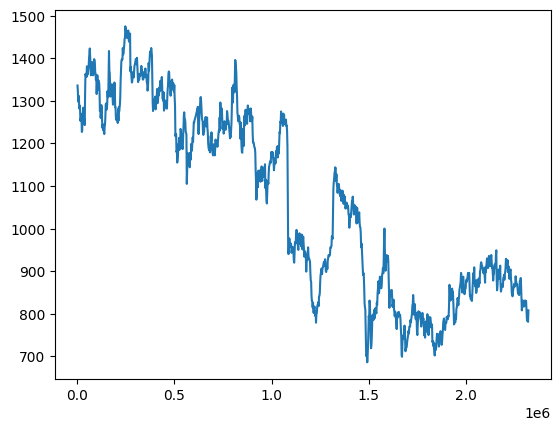

In [7]:
tmp_df = df[df['SecuritiesCode'] == 4202]
tmp_df.Close.plot()

We must select events by comparing the shifted mean average to the target value using the cumulative buy/sell directions, subject to a threshold. To achieve this, we will employ an event-based sampling technique known as the CUMSUM Filter (Lopez de Parto, 2018). However, before implementing this method, it is essential to calculate both the volatility of each security and their average volatility.

In [8]:
def get_daily_vol(close: pd.Series, span=100) -> pd.Series:
    """
    Compute the daily volatility of a time series.

    This function calculates the daily volatility of a time series using
    an exponentially weighted moving standard deviation (EWMSD) approach.

    Parameters
    ----------
    close : pd.Series
        Series containing the closing prices of the asset.
    span : int, optional
        Span parameter for the EWMSD calculation.
        Default is 100.

    Returns
    -------
    pd.Series
        Series containing the daily volatility.
    """
    # daily vol, reindexed to close
    df = close.index.searchsorted(close.index - pd.Timedelta(days=1))
    df = df[df > 0]
    df = pd.Series(close.index[df - 1], index=close.index[close.shape[0] - df.shape[0]:], name='sd').to_frame()
    df = (close.loc[df.index] / close.loc[df.sd].values) - 1 # daily return
    df = df.ewm(span=span).std()
    return df

In [9]:
def get_events(df: pd.DataFrame, threshold: Union[int, float]=0.5) -> pd.DatetimeIndex:
    """
    Identify events in a time series based on a CUMSUM filter.

    This function detects events in a time series by applying a CUMSUM filter
    to a specified target column.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing the time series data.
    threshold : Union[int, float], optional
        Threshold for detecting events.
        Default is 0.5.

    Returns
    -------
    pd.DatetimeIndex
        DatetimeIndex containing the timestamps of detected events.
    """
    events_t, s_pos, s_neg = [], 0, 0
    diff = df.Target
    for idx in diff.index:
        s_pos, s_neg = max(0, s_pos + diff.loc[idx]), min(0, s_neg + diff.loc[idx])

        if s_neg < -threshold:
            s_neg = 0; events_t.append(idx)
        elif s_pos > threshold:
            s_pos = 0; events_t.append(idx)

    return pd.DatetimeIndex(events_t)

Next, we aim to implement the triple-barrier method to categorize observations using predefined profit-taking and stop-loss thresholds. This approach is valuable for establishing profit and loss boundaries, as well as for determining return weights. Additionally, by incorporating this method, the model can identify securities that are expected to yield higher returns or experience reduced losses within a specified time frame.

In [10]:
def apply_put_sell_on_threshold(events, close, put_sell) -> pd.DataFrame:
    r"""
    Apply put option selling strategy based on given threshold values.

    This function applies a put option selling strategy to events based on specified
    threshold values for profit taking (pt) and stop loss (sl).

    Parameters
    ----------
    events : pandas.DataFrame
        DataFrame containing event information, including ``tv1`` (end of event) and
        ``trgt`` (target value).
    close : pandas.Series
        Series containing closing prices.
        This series is used to calculate path prices and returns.
    put_sell : tuple
        Tuple containing threshold values for profit taking (pt) and stop loss (sl).
        The first element represents the profit taking threshold, and
        the second element represents the stop loss threshold.

    Returns
    -------
    pandas.DataFrame
        DataFrame containing the earliest profit taking ('pt') and
        stop loss ('sl') timestamps for each event.

    Notes
    -----
    The function calculates path returns based on the closing prices from the event
    start to the end.
    Profit taking (pt) and stop loss (sl) thresholds are applied to the path returns
    to determine the respective timestamps.
    """
    # apply stop loss/profit taking, if it takes place before tv1 (end of event)
    out = events[['tv1']].copy(deep=True)
    if put_sell[0] > 0:
        pt = put_sell[0] * events['trgt']
    else:
        pt = pd.Series(index=[events.name], dtype=np.float32) # `np.nan` values

    if put_sell[1] > 0:
        sl = -put_sell[1] * events['trgt']
    else:
        sl = pd.Series(index=[events.name], dtype=np.float32) # `np.nan` values

    loc_ = events.name
    tv1 = events['tv1']

    df = close[loc_: tv1] # path prices
    df = ((df / close[loc_]) - 1) * events['side'] # path returns

    if isinstance(pt, float):
        src_ = df[df > pt].tolist()
        out['pt'] = np.min(src_) if len(src_) > 0 else np.nan
    else:
        out['pt'] = df[df > pt[loc_]].index.min() # earliest profit taking

    if isinstance(sl, float):
        src_ = df[df < sl]
        out['sl'] = np.min(src_) if len(src_) > 0 else np.nan
    else:
        out['sl'] = df[df < sl[loc_]].index.min() # earliest stop loss.
    return out

In [11]:
def get_vert_barrier(close: pd.Series,
                     t_events: pd.DatetimeIndex,
                     num_days: int) -> pd.Series:
    """
    Add a vertical barrier to events.

    Parameters
    ----------
    close : pd.Series
        Close prices of the security for given datetimes.
    t_events : pd.DatetimeIndex
        Timestamps representing event occurrences.
    num_days : int
        Number of days to define the vertical barrier.

    Returns
    -------
    pd.Series
        Timestamps indicating when the first vertical barrier is touched.

    Notes
    -----
    This function finds the timestamp of the next price bar at or immediately
    after a specified number of days from each event.
    The vertical barrier is defined as the time when the price reaches the specified
    number of days from the event timestamp.
    """
    tv1 = close.index.searchsorted(t_events + pd.Timedelta(days=num_days))
    tv1 = tv1[tv1 < close.shape[0]]
    tv1 = pd.Series(close.index[tv1], index=t_events[:tv1.shape[0]], name='tv1')  # NaNs at end
    return tv1

In [12]:
def get_tbl_events(close: pd.Series,
                   t_events: pd.DatetimeIndex,
                   put_sell: Tuple[int, int],
                   trgt: pd.Series,
                   min_ret: float,
                   tv1: Union[bool, pd.Series] = False,
                   side: Optional[pd.Series] = None) -> pd.Series:
    r"""
    Generate a table of events based on specified parameters.

    Parameters
    ----------
    close : pd.Series
        Close prices of the security for given datetimes.
    t_events : pd.DatetimeIndex
        Timestamps representing event occurrences.
    put_sell : Tuple[int, int]
        Tuple containing threshold values for profit taking (pt) and stop loss (sl).
        The first element represents the profit taking threshold,
        and the second element represents the stop loss threshold.
    trgt : pd.Series
        Series containing target values.
        These values are used for filtering events based on minimum returns/vol.
    min_ret : float
        Minimum return/vol threshold for filtering events.
        Events with target values below this threshold are discarded.
    tv1 : Union[bool, pd.Series], optional
        Series containing the timestamp of the next price bar at or immediately
        after a number of days. If False, no vertical barrier is applied. Defaults to ``False``.
    side : Optional[pd.Series], optional
        Series containing side information for each event.
        This parameter is used to specify the side of each event (e.g., 1 for long, -1 for short).
        Defaults to ``None``.

    Returns
    -------
    pd.Series
        Table of events containing the timestamp of the vertical barrier (``tv1``),
        target values (``trgt``), profit taking timestamps (``pt``),
        and stop loss timestamps (``sl``).

    Notes
    -----
    Events are filtered based on minimum return thresholds and optionally by side information.
    The vertical barrier, profit taking, and stop loss are applied to each event according
    to the specified thresholds.
    """
    # 1) get targets
    com_idx = t_events.intersection(trgt.index)
    trgt = trgt.loc[com_idx] # sampling data based on CUM Filtering
    trgt = trgt.loc[trgt > min_ret] # filter by the min returns

    # 2) get tv1 (max holding period)
    if tv1 is False:
        tv1 = pd.Series(pd.NaT)

    # 3) form events object, apply stop loss on tv1
    if side is None:
        side_, pt_sl_ = pd.Series(1., index=trgt.index), [put_sell[0], put_sell[0]]
        events = pd.concat({'tv1': tv1, 'trgt': trgt,
                            'side': side_},
                        axis=1).dropna(subset=['trgt'])
    else:
        com_idx = side.index.intersection(trgt.index)
        side_, pt_sl_ = side.loc[com_idx], put_sell[:2]
        events = pd.concat({'tv1': tv1, 'trgt': trgt,
                            'side': side_},
                            axis=1).dropna(subset=['trgt', 'side'])

    events['tv1'] = events['tv1'].fillna(close.index[-1])

    df = events.parallel_apply(apply_put_sell_on_threshold, args=(close, pt_sl_), axis=1)
    events['pt'] = df['pt']
    events['sl'] = df['sl']
    events['tv1'] = df.dropna(how='all')['tv1']
    if side is None:
        events = events.drop('side', axis=1)

    return events

In [13]:
def compute_tbl_events(df: pd.DataFrame,
                       put_sell: Tuple[int, int],
                       num_days: int = 1,
) -> pd.DataFrame:
    r"""
    Compute Triple Barriers events for each security in a DataFrame.

    This function computes Triple Barrier Labeling (TBL) events for each security
    in the provided DataFrame. It iterates over each unique ``SecuritiesCode`` and
    calculates TBL events based on the given parameters.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing the time series data for multiple securities.
    put_sell : Tuple[int, int]
        Tuple containing the multipliers for the lower and upper barriers, respectively.
    num_days : int, optional
        Number of days to wait before closing the position, by default ``1``.

    Returns
    -------
    Tuple[pd.DataFrame, pd.Series]
            - pd.DataFrame: DataFrame containing the TBL events.
    """

    df_ = pd.DataFrame()
    lst_secs = df.SecuritiesCode.unique().tolist()
    prg_bar = tqdm(enumerate(lst_secs), total=len(lst_secs),
                   desc=f'Compute Triple barriers for {num_days} position')
    for idx, sec in prg_bar:
        sec_df = df[df['SecuritiesCode'] == sec].reset_index(drop=True)
        sec_df['Date'] = pd.to_datetime(sec_df['Date'])
        sec_df = sec_df.set_index('Date')

        vol = get_daily_vol(sec_df.Close)
        avg_vol = vol.mean()

        t_events = get_events(sec_df, avg_vol)
        t1 = get_vert_barrier(sec_df.Close, t_events, num_days)
        print(f"sec: {sec}, barrier len: {t1.shape[0]}")
        if t1.shape[0] > 50:
            events = get_tbl_events(sec_df.Close, t_events, put_sell,
                                    vol, avg_vol, t1)
            sec_df = sec_df.loc[events.index]
            sec_df = sec_df.reset_index().dropna()
            df_ = pd.concat([df_, sec_df])

        if idx % 5 == 0:
            clear_output(wait=True)
            display(prg_bar.container)
    df_ = df_.sort_values(by='index').reset_index(drop=True)
    df_.columns = df_.columns[1:].insert(0, 'Date')
    return df_

Prior to computing the triple barrier, we had already stored the outcomes in a private dataset because of issues encountered during parallel computation with Kaggle. Consequently, to save time, we executed the code on Colab, where it completed processing within 1 hour and 7 minutes, utilizing only one processor. Consequently, I determined that it would be more efficient to store the results in a dataset rather than recompute them during debugging and notebook commits.

In [14]:
put_sell = (1, 1)
one_day = 1
two_days = 2
df_1, df_2 = None, None
data_path = Path('/kaggle/input/jpx-pre/')
os.makedirs(data_path, exist_ok=True)
file_name = 'tbm_data.csv'

if os.path.exists(data_path / file_name):
    df = pd.read_csv(data_path / file_name)
else:
    df_1 = compute_tbl_events(df, put_sell, one_day)
    df_2 = compute_tbl_events(df, put_sell, two_days)
    df = pd.concat([df_1, df_2])
    df = df[~df.duplicated(keep='first')]
    df = df.dropna().reset_index(drop=True)
    df.to_csv(data_path / file_name, index=False)
df

,Date,SecuritiesCode,Close,Volume,Target
0,2017-01-10,4202,1312.0,1698100,-0.014604
1,2017-01-10,2393,1380.0,173600,0.038781
2,2017-01-10,4569,2647.0,204200,-0.024105
3,2017-01-10,5021,1699.0,331500,0.075206
4,2017-01-10,9640,1274.0,1500,-0.032591
...,...,...,...,...,...
262690,2021-12-03,9201,2125.0,9747500,0.045999
262691,2021-12-03,2201,3670.0,112700,0.031507
262692,2021-12-03,1914,605.0,125100,0.032095
262693,2021-12-03,6947,3695.0,63600,0.055398


Review the securities and eliminate those with fewer than 50 samples or 1.9E-4 percent. This strategy effectively removes the rarest samples, thereby preventing them from unduly influencing the model weights.

In [15]:
df.SecuritiesCode.value_counts()

SecuritiesCode
8585    263
7979    259
6779    242
9873    237
2819    236
       ... 
8344      6
8022      6
2060      5
9982      5
8713      3
Name: count, Length: 1880, dtype: int64

In [16]:
df.SecuritiesCode.value_counts(normalize=True)

SecuritiesCode
8585    0.001001
7979    0.000986
6779    0.000921
9873    0.000902
2819    0.000898
          ...   
8344    0.000023
8022    0.000023
2060    0.000019
9982    0.000019
8713    0.000011
Name: proportion, Length: 1880, dtype: float64

In [17]:
def drop_securities(events: pd.DataFrame, min_pct: float = 1.9e-4, max_drop_sec: int = 400):
    r"""
    Review securities and eliminate those with fewer than a specified percentage of samples.

    This function reviews the securities in the provided DataFrame and
    eliminates those with fewer samples than the specified percentage.
    It iterates until all securities meet the minimum sample percentage criterion.

    Parameters
    ----------
    events : pd.DataFrame
        DataFrame containing the securities data.
    min_pct : float, optional
        Minimum percentage of samples allowed for each security, by default ``1.9e-4``.
    max_drop_sec : int, optional
        Maximum number of securities to drop, by default ``400``.
        We can't go less to fit the ranking system of the competition.

    Returns
    -------
    pd.DataFrame
        DataFrame containing the remaining securities after elimination
        based on sample percentage.
    """
    # apply weights, drop labels with insufficient examples
    events_ = events
    while True:
        df = events_['SecuritiesCode'].value_counts(normalize=True)
        if df.min() > min_pct or df.shape[0] < max_drop_sec : break
        print(f'Dropped Label ({df.idxmin()}, {df.min()})')
        events_ = events_[events_['SecuritiesCode'] != df.idxmin()]

    return events_

In [18]:
df = drop_securities(df)

Dropped Label (8713, 1.1420087934677097e-05)
Dropped Label (9982, 1.90336972576249e-05)
Dropped Label (2060, 1.9034059546151885e-05)
Dropped Label (8344, 2.284130621816493e-05)
Dropped Label (8022, 2.284182795535184e-05)
Dropped Label (9065, 2.284234971637416e-05)
Dropped Label (4046, 2.66500167514391e-05)
Dropped Label (9045, 2.665072699375992e-05)
Dropped Label (8057, 2.66514372739387e-05)
Dropped Label (1946, 2.6652147591978466e-05)
Dropped Label (2768, 2.665285794788224e-05)
Dropped Label (3946, 3.0461220961889206e-05)
Dropped Label (9008, 3.0462148876137096e-05)
Dropped Label (4183, 3.0463076846919232e-05)
Dropped Label (8584, 3.046400487424078e-05)
Dropped Label (5481, 3.4273049577870274e-05)
Dropped Label (1801, 3.4274224260057584e-05)
Dropped Label (9304, 3.427539902277029e-05)
Dropped Label (4611, 3.427657386601668e-05)
Dropped Label (5201, 3.427774878980503e-05)
Dropped Label (4044, 3.427892379414364e-05)
Dropped Label (9533, 3.808899875448974e-05)
Dropped Label (8059, 3.8090

In [19]:
df.SecuritiesCode.value_counts(normalize=True)

SecuritiesCode
8585    0.001013
7979    0.000998
6779    0.000932
9873    0.000913
2819    0.000909
          ...   
4495    0.000196
6484    0.000193
4490    0.000193
7071    0.000193
7089    0.000193
Name: proportion, Length: 1731, dtype: float64

Now that we have calculated the triple barrier events for each security, we need to recalculate the target returns to account for the alterations in the events we have identified.

In [20]:
def cal_target(df):
    """
    Calculate target returns based on given periods (1-day return, 2-day returns).

    This function calculates target returns for each security in the provided DataFrame.
    It computes the percentage change in the closing price between the current day and the next day,
    and between the current day and the day after next, representing 1-day and 2-day returns respectively.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing the time series data for multiple securities.

    Returns
    -------
    pd.DataFrame
        DataFrame containing the calculated target returns for each security.
    """
    df_ = pd.DataFrame()
    lst_secs = df.SecuritiesCode.unique().tolist()
    prg_bar = tqdm(enumerate(lst_secs), total=len(lst_secs),
                   desc=f'Compute Target Returns')
    for _, sec in prg_bar:
        sec_df = df[df['SecuritiesCode'] == sec].reset_index(drop=True)
        sec_df['Date'] = pd.to_datetime(sec_df['Date'])
        sec_df = sec_df.set_index('Date')

        # ref: https://www.kaggle.com/code/chumajin/easy-to-understand-the-competition?scriptVersionId=94143164&cellId=17
        sec_df["Close_shift1"] = sec_df["Close"].shift(-1)
        sec_df["Close_shift2"] = sec_df["Close"].shift(-2)
        sec_df["Target"] = (sec_df["Close_shift2"] - sec_df["Close_shift1"]) / sec_df["Close_shift1"]
        sec_df = sec_df[['SecuritiesCode', 'Close', 'Volume', 'Target']]

        sec_df = sec_df.dropna().reset_index()
        df_ = pd.concat([df_, sec_df])
    df_ = df_.sort_values(by='Date').reset_index(drop=True)
    return df_

In [21]:
df = cal_target(df)
df

Compute Target Returns:   0%|          | 0/1731 [00:00<?, ?it/s]

,Date,SecuritiesCode,Close,Volume,Target
0,2017-01-10,4202,1312.0,1698100,0.000000
1,2017-01-10,2296,1077.0,393700,0.028986
2,2017-01-10,8157,639.0,9500,-0.013158
3,2017-01-10,9960,1798.0,9800,-0.020373
4,2017-01-10,8249,1126.0,7300,0.017593
...,...,...,...,...,...
256078,2021-12-01,3319,1036.0,136300,0.034716
256079,2021-12-01,7596,1960.0,6800,0.015152
256080,2021-12-01,2158,2900.0,71400,-0.228385
256081,2021-12-01,7201,558.0,26110100,0.040553


Let's have the volume weighted average price (VWAP) of each equity

In [22]:
from jpx_ranker import compute_vwap

INFO: Pandarallel will run on 3 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [23]:
df = compute_vwap(df)
df

Compute VWAP:   0%|          | 0/1731 [00:00<?, ?it/s]

,Date,SecuritiesCode,Close,VWAP,Target,vwap_rate
0,2017-01-10,4202,1312.0,1312.000000,0.000000,-0.025163
1,2017-01-10,3962,5290.0,5290.000000,-0.144385,-0.010291
2,2017-01-10,5807,1304.0,1304.000000,0.064343,0.045755
3,2017-01-10,2914,3887.0,3887.000000,-0.035769,-0.023700
4,2017-01-10,4544,5300.0,5300.000000,-0.005807,-0.011281
...,...,...,...,...,...,...
252616,2021-11-26,7201,628.9,483.734099,-0.008705,0.000931
252617,2021-11-29,2931,827.0,873.423470,-0.033962,-0.001259
252618,2021-11-29,6182,1074.0,2848.565796,0.024911,-0.005056
252619,2021-11-29,2158,4300.0,1332.350703,-0.194444,0.000322


In [24]:
df[df.SecuritiesCode == 4202]

,Date,SecuritiesCode,Close,VWAP,Target,vwap_rate
0,2017-01-10,4202,1312.0,1312.000000,0.000000,-0.025163
26464,2018-04-02,4202,1164.0,1265.342312,-0.002577,-0.016844
26792,2018-04-03,4202,1164.0,1233.501881,0.018949,-0.004053
27298,2018-04-06,4202,1161.0,1212.724731,0.049873,0.007783
27878,2018-04-12,4202,1183.0,1207.809768,-0.095813,-0.011374
...,...,...,...,...,...,...
237896,2021-05-20,4202,852.0,859.100957,0.031579,0.000122
244284,2021-08-05,4202,855.0,859.064503,0.001134,0.000066
244419,2021-08-10,4202,882.0,859.168924,0.004530,0.000099
244896,2021-08-16,4202,883.0,859.225396,-0.022548,0.000016


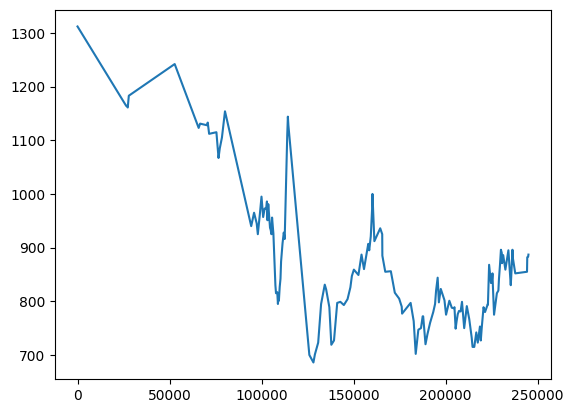

In [25]:
tmp_df = df[df['SecuritiesCode'] == 4202]
plt.plot(tmp_df['Close'])
plt.show()

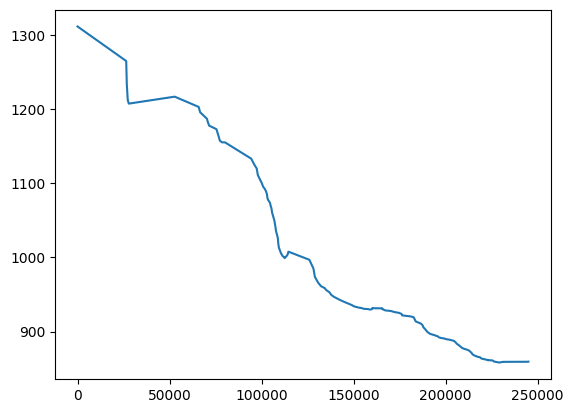

In [26]:
plt.plot(tmp_df['VWAP'])
plt.show()

After comparing the charts for the selected security before and after applying our preprocessing steps, we observe a significant change in distribution. This improved distribution, achieved through our preprocessing, effectively targets long and short positions for entering and exiting the market for each security. Consequently, training a model to rank these positions becomes critical for guiding investor decisions and determining which securities to invest in or take a short position on, thereby refining the model's decision boundary and enhancing precision.

Now, let's conduct a stationarity test on both the `Target` and `rate_vwap` variables to determine which one to utilize in our subsequent processes.


In [27]:
stats = adfuller(tmp_df.Target)
t_test, p_value = stats[:2]
t_test, p_value

(-9.148340768028065, 2.7291421993867407e-15)

In [28]:
stats = adfuller(tmp_df.VWAP)
t_test, p_value = stats[:2]
t_test, p_value

(-5.2270439619290885, 7.740507794322504e-06)

## Feature Engineering

In [29]:
from jpx_ranker import compute_feature_eng

In [30]:
fast_period = 5
slow_period = 10

df = compute_feature_eng(df, fast_period, slow_period)
df

Compute Securities Features: 100%|#########9| 1729/1731 [04:56<00:00, 10.31it/s]

,Date,SecuritiesCode,Close,VWAP,Target,vwap_rate,side,vol5,vol10,vol15,vol21,autocorr-10,autocorr-15,autocorr-21
0,2017-01-12,3902,2530.0,2565.711458,-0.045499,-0.065895,1.0,0.086390,0.086390,0.086390,0.086390,-1.000000,-1.000000,-1.000000
1,2017-01-13,2393,1488.0,1443.132757,-0.063366,-0.002023,1.0,0.041620,0.041620,0.041620,0.041620,-1.000000,-1.000000,-1.000000
2,2017-01-13,3778,1134.0,1108.867086,-0.005168,0.002756,1.0,0.083890,0.083890,0.083890,0.083890,1.000000,1.000000,1.000000
3,2017-01-13,8291,337.0,342.333720,0.024024,0.000079,1.0,0.020683,0.020683,0.020683,0.020683,-1.000000,-1.000000,-1.000000
4,2017-01-13,6904,628.0,605.052614,-0.047386,-0.004580,1.0,0.069681,0.069681,0.069681,0.069681,1.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249154,2021-11-26,7169,1273.0,1923.703445,0.049421,-0.003565,1.0,0.058295,0.107104,0.092151,0.086414,0.348258,0.385422,0.433330
249155,2021-11-29,2158,4300.0,1332.350703,-0.194444,0.000322,-1.0,0.157201,0.195384,0.162123,0.141544,0.121414,0.135910,0.122663
249156,2021-11-29,2931,827.0,873.423470,-0.033962,-0.001259,-1.0,0.021157,0.072776,0.061889,0.054842,-0.262161,-0.195706,-0.173842
249157,2021-11-29,6912,1190.0,1098.566033,0.050420,0.000889,-1.0,0.165028,0.117723,0.100211,0.088920,-0.240556,-0.188016,-0.065297


/tmp/ipykernel_47/1620253031.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['side'] = df['side'].astype(int)


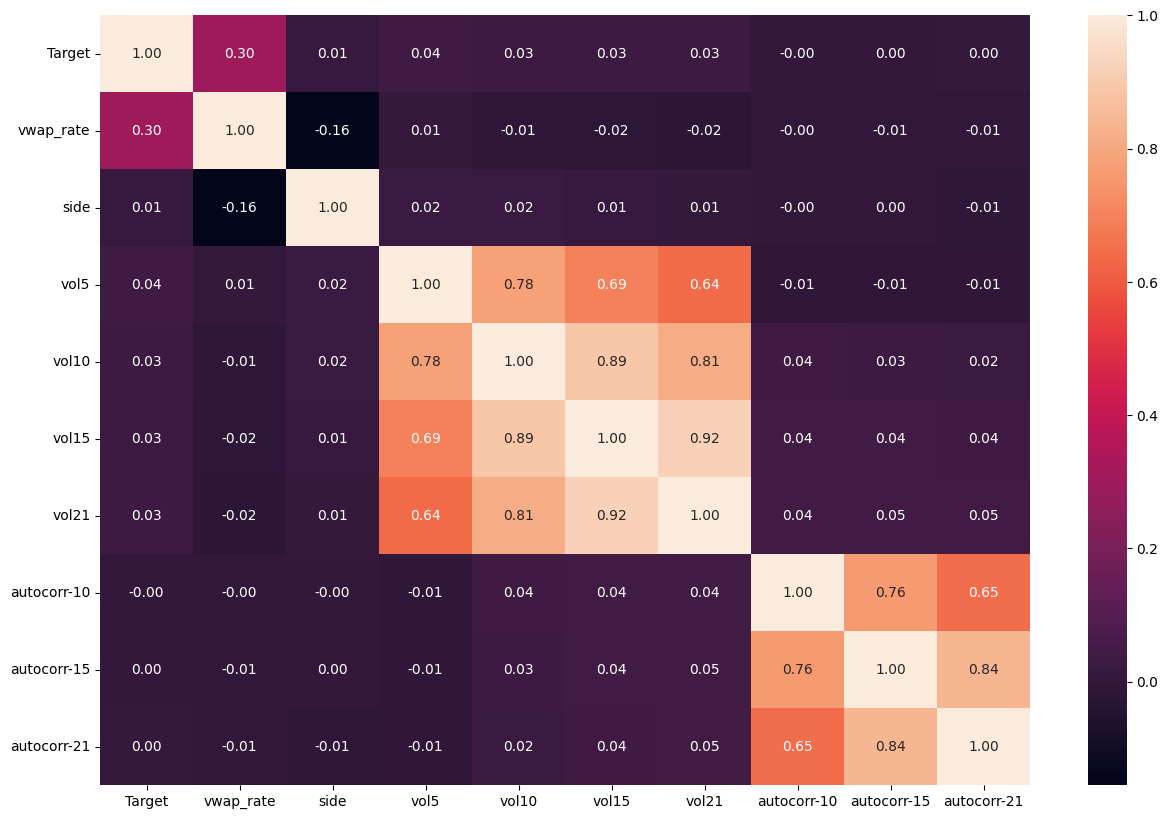

In [31]:
df = df[['Date', 'SecuritiesCode', 'Target', 'vwap_rate', 'side', 'vol5', 'vol10', 'vol15', 'vol21', 'autocorr-10', 'autocorr-15', 'autocorr-21']]
df['side'] = df['side'].astype(int)

# Compute correlation across all data (not grouped by SecuritiesCode and Date)
# since groupby().corr() on those columns leaves no variation within groups
df_vis = df[['Target', 'vwap_rate', 'side', 'vol5', 'vol10', 'vol15', 'vol21', 'autocorr-10', 'autocorr-15', 'autocorr-21']].corr()

plt.figure(figsize=(15, 10))
sns.heatmap(df_vis, annot=True, fmt='.2f')
plt.show()

In [32]:
correlation_df = df.groupby('SecuritiesCode').corr().droplevel(0)
correlation_df

,Date,Target,vwap_rate,side,vol5,vol10,vol15,vol21,autocorr-10,autocorr-15,autocorr-21
Date,1.000000,0.056015,-0.423988,-0.023830,-0.120124,-0.217369,-0.279847,-0.320791,0.102021,0.056290,0.080443
Target,0.056015,1.000000,0.269310,0.026542,0.033990,0.022502,0.039906,0.086982,0.032114,-0.024792,-0.095044
vwap_rate,-0.423988,0.269310,1.000000,-0.236254,0.111643,0.350108,0.424772,0.537932,-0.291876,-0.370453,-0.451962
side,-0.023830,0.026542,-0.236254,1.000000,0.310637,0.165932,0.062312,-0.042634,-0.143246,-0.065824,-0.074841
vol5,-0.120124,0.033990,0.111643,0.310637,1.000000,0.750321,0.615482,0.520007,-0.254414,-0.385002,-0.412071
...,...,...,...,...,...,...,...,...,...,...,...
vol15,-0.363001,-0.112729,-0.432985,0.294844,0.495200,0.763549,1.000000,0.779936,-0.023929,-0.024494,-0.058172
vol21,-0.396985,-0.091476,-0.436988,0.195880,0.411854,0.585507,0.779936,1.000000,-0.192553,-0.137261,-0.071564
autocorr-10,0.036805,-0.195048,-0.158811,0.262414,-0.070580,-0.030941,-0.023929,-0.192553,1.000000,0.803299,0.690604
autocorr-15,0.102561,-0.224712,-0.173711,0.251680,-0.054582,-0.031185,-0.024494,-0.137261,0.803299,1.000000,0.832586


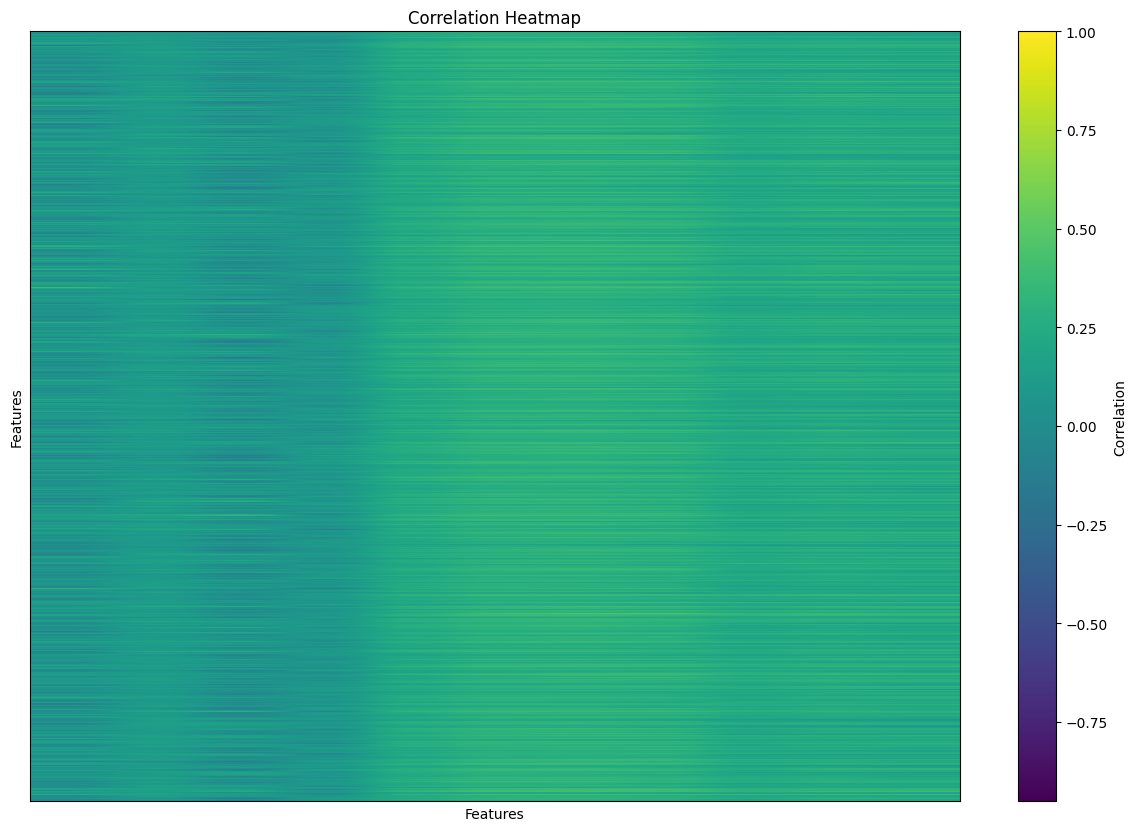

In [33]:
plt.figure(figsize=(15, 10))
plt.imshow(correlation_df.values, cmap='viridis', aspect='auto')
plt.colorbar(label='Correlation')
plt.xticks(ticks=[])
plt.yticks(ticks=[])
plt.title('Correlation Heatmap')
plt.xlabel('Features')
plt.ylabel('Features')
plt.show()

In [34]:
df = df[['Date', 'SecuritiesCode', 'Target', 'vwap_rate', 'side', 'vol5', 'vol10', 'vol15', 'vol21', 'autocorr-10', 'autocorr-15', 'autocorr-21']]
df['Rank'] = df.groupby("Date")["Target"].rank(ascending=False,method="first") - 1
df['Rank'] = df['Rank'].astype('int')
df

,Date,SecuritiesCode,Target,vwap_rate,side,vol5,vol10,vol15,vol21,autocorr-10,autocorr-15,autocorr-21,Rank
0,2017-01-12,3902,-0.045499,-0.065895,1,0.086390,0.086390,0.086390,0.086390,-1.000000,-1.000000,-1.000000,0
1,2017-01-13,2393,-0.063366,-0.002023,1,0.041620,0.041620,0.041620,0.041620,-1.000000,-1.000000,-1.000000,4
2,2017-01-13,3778,-0.005168,0.002756,1,0.083890,0.083890,0.083890,0.083890,1.000000,1.000000,1.000000,2
3,2017-01-13,8291,0.024024,0.000079,1,0.020683,0.020683,0.020683,0.020683,-1.000000,-1.000000,-1.000000,0
4,2017-01-13,6904,-0.047386,-0.004580,1,0.069681,0.069681,0.069681,0.069681,1.000000,1.000000,1.000000,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
249154,2021-11-26,7169,0.049421,-0.003565,1,0.058295,0.107104,0.092151,0.086414,0.348258,0.385422,0.433330,0
249155,2021-11-29,2158,-0.194444,0.000322,-1,0.157201,0.195384,0.162123,0.141544,0.121414,0.135910,0.122663,3
249156,2021-11-29,2931,-0.033962,-0.001259,-1,0.021157,0.072776,0.061889,0.054842,-0.262161,-0.195706,-0.173842,2
249157,2021-11-29,6912,0.050420,0.000889,-1,0.165028,0.117723,0.100211,0.088920,-0.240556,-0.188016,-0.065297,0


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249159 entries, 0 to 249158
Data columns (total 13 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Date            249159 non-null  datetime64[ns]
 1   SecuritiesCode  249159 non-null  int64         
 2   Target          249159 non-null  float64       
 3   vwap_rate       249159 non-null  float64       
 4   side            249159 non-null  int64         
 5   vol5            249159 non-null  float64       
 6   vol10           249159 non-null  float64       
 7   vol15           249159 non-null  float64       
 8   vol21           249159 non-null  float64       
 9   autocorr-10     249159 non-null  float64       
 10  autocorr-15     249159 non-null  float64       
 11  autocorr-21     249159 non-null  float64       
 12  Rank            249159 non-null  int64         
dtypes: datetime64[ns](1), float64(9), int64(3)
memory usage: 24.7 MB


In [36]:
df = df.reset_index(drop=True)
df.to_feather('/kaggle/working/preped_data.feather')

---

## 📊 Data Preparation & Modeling

Prepare the processed data and train ranking models for stock prediction.

In [2]:
from jpx_ranker import compute_vwap
from jpx_ranker import compute_feature_eng

INFO: Pandarallel will run on 11 workers.
INFO: Pandarallel will use standard multiprocessing data transfer (pipe) to transfer data between the main process and workers.


In [3]:
df = pd.read_feather('../kaggle/working/preped_data.feather')
df

,Date,SecuritiesCode,Target,vwap_rate,side,vol5,vol10,vol15,vol21,autocorr-10,autocorr-15,autocorr-21,Rank
0,2017-01-12,3902,-0.045499,-0.065895,1,0.086390,0.086390,0.086390,0.086390,-1.000000,-1.000000,-1.000000,0
1,2017-01-13,2393,-0.063366,-0.002023,1,0.041620,0.041620,0.041620,0.041620,-1.000000,-1.000000,-1.000000,4
2,2017-01-13,3778,-0.005168,0.002756,1,0.083890,0.083890,0.083890,0.083890,1.000000,1.000000,1.000000,2
3,2017-01-13,8291,0.024024,0.000079,1,0.020683,0.020683,0.020683,0.020683,-1.000000,-1.000000,-1.000000,0
4,2017-01-13,6904,-0.047386,-0.004580,1,0.069681,0.069681,0.069681,0.069681,1.000000,1.000000,1.000000,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
249154,2021-11-26,7169,0.049421,-0.003565,1,0.058295,0.107104,0.092151,0.086414,0.348258,0.385422,0.433330,0
249155,2021-11-29,2158,-0.194444,0.000322,-1,0.157201,0.195384,0.162123,0.141544,0.121414,0.135910,0.122663,3
249156,2021-11-29,2931,-0.033962,-0.001259,-1,0.021157,0.072776,0.061889,0.054842,-0.262161,-0.195706,-0.173842,2
249157,2021-11-29,6912,0.050420,0.000889,-1,0.165028,0.117723,0.100211,0.088920,-0.240556,-0.188016,-0.065297,0


In [4]:
df_test = pd.read_csv('../kaggle/input/jpx-tokyo-stock-exchange-prediction/supplemental_files/stock_prices.csv')
df_test

,RowId,Date,SecuritiesCode,Open,High,Low,Close,Volume,AdjustmentFactor,ExpectedDividend,SupervisionFlag,Target
0,20211206_1301,2021-12-06,1301,2982.0,2982.0,2965.0,2971.0,8900,1.0,NaN,False,-0.003263
1,20211206_1332,2021-12-06,1332,592.0,599.0,588.0,589.0,1360800,1.0,NaN,False,-0.008993
2,20211206_1333,2021-12-06,1333,2368.0,2388.0,2360.0,2377.0,125900,1.0,NaN,False,-0.009963
3,20211206_1375,2021-12-06,1375,1230.0,1239.0,1224.0,1224.0,81100,1.0,NaN,False,-0.015032
4,20211206_1376,2021-12-06,1376,1339.0,1372.0,1339.0,1351.0,6200,1.0,NaN,False,0.002867
...,...,...,...,...,...,...,...,...,...,...,...,...
269876,20220624_9990,2022-06-24,9990,576.0,576.0,563.0,564.0,24200,1.0,NaN,False,0.027073
269877,20220624_9991,2022-06-24,9991,810.0,815.0,804.0,815.0,8700,1.0,NaN,False,0.001220
269878,20220624_9993,2022-06-24,9993,1548.0,1548.0,1497.0,1497.0,12600,1.0,NaN,False,0.001329
269879,20220624_9994,2022-06-24,9994,2507.0,2527.0,2498.0,2527.0,7300,1.0,NaN,False,0.003185


In [5]:
fast_period = 5
slow_period = 10

# Check if the test preprocessing data is already exists previously:
if os.path.exists('../kaggle/working/test_preped_data.feather'):
    df_fet_test = pd.read_feather('../kaggle/working/test_preped_data.feather')
else:
    df_fet_test = df_test[['Date', 'SecuritiesCode', 'Close', 'Volume', 'Target']].dropna().reset_index(drop=True)
    df_fet_test = compute_vwap(df_fet_test)
    df_fet_test = compute_feature_eng(df_fet_test, fast_period, slow_period)
    df_fet_test = df_fet_test[['Date', 'SecuritiesCode', 'Target', 'vwap_rate', 'side', 'vol5', 'vol10', 'vol15', 'vol21', 'autocorr-10', 'autocorr-15', 'autocorr-21']]
    df_fet_test['Rank'] = df_fet_test.groupby("Date")["Target"].rank(ascending=False,method="first") - 1
    df_fet_test['Rank'] = df_fet_test['Rank'].astype('int')
    df_fet_test.to_feather('../kaggle/working/test_preped_data.feather')

df_fet_test

,Date,SecuritiesCode,Target,vwap_rate,side,vol5,vol10,vol15,vol21,autocorr-10,autocorr-15,autocorr-21,Rank
0,2021-12-08,1301,0.006483,0.003943,1.0,0.006798,0.006798,0.006798,0.006798,-1.000000,-1.000000,-1.000000,229
1,2021-12-08,9039,-0.001149,-0.001976,1.0,0.011513,0.011513,0.011513,0.011513,-1.000000,-1.000000,-1.000000,585
2,2021-12-08,7581,-0.009804,-0.000126,1.0,0.010906,0.010906,0.010906,0.010906,-1.000000,-1.000000,-1.000000,1129
3,2021-12-08,2175,-0.016985,0.007379,1.0,0.033579,0.033579,0.033579,0.033579,-1.000000,-1.000000,-1.000000,1456
4,2021-12-08,6742,0.030238,0.019414,1.0,0.015312,0.015312,0.015312,0.015312,-1.000000,-1.000000,-1.000000,24
...,...,...,...,...,...,...,...,...,...,...,...,...,...
261020,2022-06-22,4471,0.012917,-0.000462,1.0,0.016992,0.013699,0.011785,0.012006,-0.246049,-0.150591,-0.117192,833
261021,2022-06-22,6823,0.007475,0.000067,1.0,0.014206,0.024808,0.022947,0.020255,-0.576017,-0.464550,-0.360416,1077
261022,2022-06-22,3854,0.014013,0.000962,1.0,0.024624,0.026386,0.043903,0.038565,0.206552,-0.292716,-0.315033,769
261023,2022-06-22,7516,0.012517,0.000080,1.0,0.010558,0.011919,0.013504,0.012557,0.116348,-0.079125,-0.091047,848


After preprocessing our dataset and incorporating additional features, the next step is to prepare our dataset for training with a ranking model. The ranking model enables us to train models based on the extracted features and obtain the rank of each security's features. 

To avoid overfitting and data leakage in financial time series, we utilize an advanced cross-validation technique called **CombinatorialPurgedCV** from [skfolio](https://skfolio.org/generated/skfolio.model_selection.CombinatorialPurgedCV.html), which is specifically designed for financial machine learning. This approach offers significant advantages over standard `TimeSeriesSplit`:

- **Purging**: Removes training observations whose labels overlap in time with test labels, preventing leakage from multi-day return calculations
- **Embargoing**: Excludes observations immediately following test periods to handle serial correlation in financial features (ARMA processes, momentum effects)
- **Combinatorial Paths**: Creates multiple train/test combinations for more robust validation (e.g., C(10,2) = 45 splits instead of just 5)

Our implementation trains three state-of-the-art ranking models (`LGBMRanker`, `XGBRanker`, and `CatBoostRanker`) using **Optuna** for hyperparameter optimization. The best performing model is automatically selected based on validation NDCG@100 scores.

Additionally, we've developed a modular, professional pipeline architecture with:
- **DataProcessor**: Unified data preparation for all three frameworks
- **ModelSelector**: Automated model training, comparison, and selection
- **TrainingPipeline**: Complete training orchestration with evaluation
- **InferencePipeline**: Kaggle-compatible submission generation

This approach follows best practices from "Advances in Financial Machine Learning" by Marcos López de Prado, ensuring robust and production-ready algorithmic trading models.

In [6]:
train = df.copy(deep=True)
test = df_fet_test.copy(deep=True)

In [7]:
from jpx_ranker import calc_spread_return_sharpe
from jpx_ranker import calc_spread_return_sharpe_scorer

### 🔧 Data Processing

Initialize the `DataProcessor` to prepare data for model training.

In [8]:
from jpx_ranker import DataProcessor

### 🎯 Model Training

Train multiple ranking models with Optuna hyperparameter optimization and select the best performer.

In [9]:
from jpx_ranker import TrainingPipeline

In [10]:
TRAIN_CONFIG = {
    'test_size': 0.2,          # Validation split ratio (20% for validation)
    'n_trials': 200,           # Optuna trials per model (increase for better optimization)
    'n_folds': 10,             # Number of folds for CombinatorialPurgedCV
    'n_test_folds': 2,         # Number of test folds per split
    'purged_size': 2,          # Days to purge around test sets (prevents label leakage)
    'embargo_size': 21,         # Days to embargo after test sets (handles serial correlation)
    'seed': 42,                # Random seed for reproducibility
    'save_model_path': '../kaggle/working/best_ranker_model.pkl',
    'device': 'cpu',           # Change to 'cuda' when submitting to Kaggle with GPU
    'min_trials': 10            # Minimum number of trials before checking for early stopping
}

# Feature engineering parameters (if needed)
UPDATED_FEATURE_CONFIG = {
    'fast_period': 5,
    'slow_period': 10
}

print("✓ Updated Configuration Loaded")
print(f"  Training config: {TRAIN_CONFIG}")
print(f"  Feature config: {UPDATED_FEATURE_CONFIG}")
print(f"\n  Note: Set n_trials=200 for production, n_trials=3 for quick testing")

✓ Updated Configuration Loaded
  Training config: {'test_size': 0.2, 'n_trials': 200, 'n_folds': 10, 'n_test_folds': 2, 'purged_size': 2, 'embargo_size': 21, 'seed': 42, 'save_model_path': '../kaggle/working/best_ranker_model.pkl', 'device': 'cpu', 'min_trials': 10}
  Feature config: {'fast_period': 5, 'slow_period': 10}

  Note: Set n_trials=200 for production, n_trials=3 for quick testing


In [11]:
# Updated Training Pipeline with Fixed Model Names and Result Keys
# This cell uses the corrected configuration and properly accesses result dictionary keys

print("="*80)
print("STARTING MODEL TRAINING WITH UPDATED PIPELINE")
print("="*80)
print(f"Training data shape: {df.shape}")
print(f"Features: {df.columns.tolist()}\n")

# Initialize the training pipeline with updated configuration
pipeline = TrainingPipeline(
    test_size=TRAIN_CONFIG['test_size'],
    n_trials=TRAIN_CONFIG['n_trials'],
    n_folds=TRAIN_CONFIG['n_folds'],
    n_test_folds=TRAIN_CONFIG['n_test_folds'],
    purged_size=TRAIN_CONFIG['purged_size'],
    embargo_size=TRAIN_CONFIG['embargo_size'],
    seed=TRAIN_CONFIG['seed'],
    device=TRAIN_CONFIG['device'],
    min_trials=TRAIN_CONFIG['min_trials'],
)

print(f"Pipeline initialized with:")
print(f"  - Test size: {TRAIN_CONFIG['test_size']}")
print(f"  - Optuna trials per model: {TRAIN_CONFIG['n_trials']}")
print(f"  - CV folds: {TRAIN_CONFIG['n_folds']}")
print(f"  - Purge/Embargo: {TRAIN_CONFIG['purged_size']}/{TRAIN_CONFIG['embargo_size']} days")
print(f"  - Device: {TRAIN_CONFIG['device']}\n")

# Train the models (LightGBM, XGBoost, CatBoost)
print("Training models with Optuna hyperparameter optimization...")
pipeline.fit(df, save_path=TRAIN_CONFIG['save_model_path'])

# Display comprehensive results
print("\n" + "="*80)
print("FINAL TRAINING RESULTS")
print("="*80)
print(f"✓ Best Model: {pipeline.model_selector_.best_model_name_}")
print(f"✓ Best NDCG@100 Score: {pipeline.model_selector_.best_score_:.6f}")
print(f"✓ Training Sharpe Ratio: {pipeline.train_score_:.6f}")
print(f"✓ Validation Sharpe Ratio: {pipeline.val_score_:.6f}")

# Display detailed results for all models (using correct dictionary keys)
print("\n" + "-"*80)
print("DETAILED MODEL COMPARISON")
print("-"*80)
for model_name, results in pipeline.model_selector_.model_results_.items():
    print(f"\n{model_name}:")
    print(f"  ├─ NDCG@100:          {results['best_ndcg']:.6f}")
    print(f"  ├─ Best Sharpe:       {results['best_sharpe']:.6f}")
    print(f"  ├─ Trials Completed:  {results['n_trials_completed']}")
    print(f"  └─ Best Params:       {results['best_params']}")

print("\n" + "="*80)
print(f"✓ Model saved to: {TRAIN_CONFIG['save_model_path']}")
print("="*80)

[I 2026-01-13 23:17:29,049] A new study created in memory with name: no-name-4a548337-7be8-4ec0-bba6-8b17f00aa1d0


STARTING MODEL TRAINING WITH UPDATED PIPELINE
Training data shape: (249159, 13)
Features: ['Date', 'SecuritiesCode', 'Target', 'vwap_rate', 'side', 'vol5', 'vol10', 'vol15', 'vol21', 'autocorr-10', 'autocorr-15', 'autocorr-21', 'Rank']

Pipeline initialized with:
  - Test size: 0.2
  - Optuna trials per model: 200
  - CV folds: 10
  - Purge/Embargo: 2/21 days
  - Device: cpu

Training models with Optuna hyperparameter optimization...
TRAINING PIPELINE START

[1/4] Splitting data...
Train samples: 211,375 | Val samples: 37,784
Train dates: 2017-01-12 00:00:00 to 2020-12-07 00:00:00
Val dates: 2020-12-08 00:00:00 to 2021-11-29 00:00:00

[2/4] Training models...

Training LightGBM with CPCV + Optuna
Cumulative trials so far: 0


  0%|          | 0/200 [00:00<?, ?it/s]

Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[31]	valid_0's ndcg@10: 0.994088	valid_0's ndcg@50: 0.997407	valid_0's ndcg@100: 0.998394
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[20]	valid_0's ndcg@10: 0.989116	valid_0's ndcg@50: 0.990229	valid_0's ndcg@100: 0.993092
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[33]	valid_0's ndcg@10: 0.986395	valid_0's ndcg@50: 0.985066	valid_0's ndcg@100: 0.989606
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[19]	valid_0's ndcg@10: 0.976145	valid_0's ndcg@50: 0.974936	valid_0's ndcg@100: 0.979092
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[27]	valid_0's ndcg@10: 0.96674	valid_0's ndcg@50: 0.958439	valid_0's ndcg@100: 0.960085
Training until validation scores don't improve for 30 rounds
Early stop

2026-01-13 23:19:02.909 | DEBUG    | jpx_ranker._src.model_selection:__call__:86 - MinTRL: Collecting trials (1/10 needed before stopping check)


...

[I 2026-01-14 01:01:10,516] Trial 2 finished with values: [0.9907930562492755, 0.2048414281220778] and parameters: {'learning_rate': 0.06272924049005918, 'iterations': 200, 'depth': 6, 'l2_leaf_reg': 5.72280788469014, 'border_count': 128, 'bagging_temperature': 2.9122914019804194, 'random_strength': 0.0032112643094417484}.


2026-01-14 01:38:07.370 | DEBUG    | jpx_ranker._src.model_selection:__call__:145 - MinTRL: Significance reached but model needs more exploration (4/5)...


[I 2026-01-14 01:38:07,363] Trial 3 finished with values: [0.9908005756394259, 0.20784147251913876] and parameters: {'learning_rate': 0.05045321958909213, 'iterations': 300, 'depth': 6, 'l2_leaf_reg': 5.104629857953324, 'border_count': 207, 'bagging_temperature': 1.9967378215835974, 'random_strength': 0.00042472707398058225}.


2026-01-14 01:58:34.822 | DEBUG    | jpx_ranker._src.model_selection:__call__:140 - MinTRL Status (K_global=20, K_model=5): Best SR=1.0712, PSR=1.000, T=190/2 needed
2026-01-14 01:58:34.823 | INFO     | jpx_ranker._src.model_selection:__call__:149 - 
✓ Early stopping: no-name-45c279f2-e466-45f5-949b-b9f881ed8adb reached MinTRL significance. (T=190, PSR=1.000, K_global=20, K_model=5)


[I 2026-01-14 01:58:34,816] Trial 4 finished with values: [0.9905988976313879, 0.21029031094278866] and parameters: {'learning_rate': 0.18180022496999232, 'iterations': 100, 'depth': 8, 'l2_leaf_reg': 2.5347171131856236, 'border_count': 46, 'bagging_temperature': 9.488855372533333, 'random_strength': 4.905556676028774}.

Best NDCG: 0.9908
Predicted Sharpe: 1.0687
Trials completed: 5/200
Best No. of Trials: 2

STATISTICAL VALIDATION REPORT
Best Model: CatBoost
Best NDCG: 0.9908
Best Sharpe Difference (minimized): 0.9908
Predicted Sharpe Ratio (Daily): 1.0687
Annualized Sharpe Ratio: 16.9646

⚠️  LEAKAGE WARNING: Annualized SR (16.96) is institutionally impossible!
    This indicates the competition's target data contains inherent lookahead bias.
    Even with CPCV purging/embargoing, the provided 'Target' column uses future data.
    Results are valid for competition ranking but NOT for live trading.

Raw Sharpe Ratio: 1.0687
Expected Max SR (haircut): 0.0393
Deflated Sharpe Ratio (DSR)

---

## 🚀 Kaggle Submission

Generate predictions and submit to the Kaggle competition.

### Option 1: Automated Submission (Recommended)

Use the `run_kaggle_submission` function for a complete, production-ready submission workflow with automatic validation.

In [12]:
from kaggle_submission import run_kaggle_submission

In [13]:
run_kaggle_submission(
    model_path='../kaggle/working/best_ranker_model.pkl',
    fast_period=5,
    slow_period=10,
    enable_submission=False  # Test mode
)


KAGGLE SUBMISSION: DISABLED (Local Testing Mode)

To enable Kaggle submission:
  1. Set enable_submission=True
  2. Ensure the model is saved at: ../kaggle/working/best_ranker_model.pkl
  3. Run this in the Kaggle notebook environment

For local testing, use the InferencePipeline class directly:
  >>> from jpx_ranker._src.infer import InferencePipeline
  >>> inference_pipeline = InferencePipeline(model=trained_model)
  >>> predictions = inference_pipeline.predict(test_data)


In [14]:
from jpx_ranker import InferencePipeline
from jpx_ranker import calc_spread_return_sharpe

# The pipeline automatically extracts the best model and the matching data processor
inference_pipeline = InferencePipeline(model=pipeline) 
predictions = inference_pipeline.predict(df_test)
predictions

Compute Securities Features: 100%|#########9| 1995/2000 [04:05<00:00, 10.28it/s]

,Date,SecuritiesCode,Target,Rank,Score,PredictedRank,Close,VWAP,vwap_rate,side,vol5,vol10,vol15,vol21,autocorr-10,autocorr-15,autocorr-21
0,2021-12-08,7826,0.119247,0,2.530926,6,9700.0,9588.963848,0.055264,1.0,0.072416,0.072416,0.072416,0.072416,-1.000000,-1.000000,-1.000000
1,2021-12-08,4772,0.088889,1,3.660422,0,180.0,179.983900,0.086838,1.0,0.052987,0.052987,0.052987,0.052987,1.000000,1.000000,1.000000
2,2021-12-08,6047,0.086675,2,2.601840,3,754.0,732.587817,0.066521,1.0,0.030920,0.030920,0.030920,0.030920,-1.000000,-1.000000,-1.000000
3,2021-12-08,4550,0.080235,3,2.950819,1,1014.0,996.245314,0.065648,1.0,0.040121,0.040121,0.040121,0.040121,-1.000000,-1.000000,-1.000000
4,2021-12-08,9086,0.076923,4,2.866795,2,5260.0,5196.699087,0.046568,1.0,0.047622,0.047622,0.047622,0.047622,-1.000000,-1.000000,-1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260173,2022-06-22,4541,-0.038356,1982,-0.232698,1812,358.0,429.399518,-0.000812,1.0,0.026276,0.021791,0.026061,0.045182,-0.157956,0.073655,-0.163941
260174,2022-06-22,7013,-0.052980,1983,0.739394,23,3810.0,2982.456201,0.002882,1.0,0.040687,0.027344,0.030610,0.031913,-0.154657,0.018904,-0.054306
260175,2022-06-22,4883,-0.060491,1984,0.411643,130,449.0,449.098739,0.002556,1.0,0.103726,0.089553,0.073995,0.077269,-0.247704,-0.266207,-0.300761
260176,2022-06-22,7211,-0.086066,1985,0.728324,26,482.0,343.070212,0.005535,-1.0,0.057006,0.045054,0.039094,0.034313,-0.233474,-0.085598,-0.118358


In [15]:
eval_df = predictions[['Date', 'SecuritiesCode', 'Target', 'Rank', 'Score', 'PredictedRank']].sort_values(by=['Date', 'PredictedRank'])
eval_df = eval_df.drop(columns=['Rank'])
eval_df = eval_df.rename(columns={'PredictedRank': 'Rank'})
eval_df

,Date,SecuritiesCode,Target,Score,Rank
1,2021-12-08,4772,0.088889,3.660422,0
3,2021-12-08,4550,0.080235,2.950819,1
4,2021-12-08,9086,0.076923,2.866795,2
2,2021-12-08,6047,0.086675,2.601840,3
7,2021-12-08,7911,0.053787,2.590131,4
...,...,...,...,...,...
258416,2022-06-22,9104,0.039162,-0.708153,1982
258455,2022-06-22,4828,0.035764,-0.710116,1983
258210,2022-06-22,4165,0.101604,-0.730393,1984
260177,2022-06-22,6047,-0.158730,-0.857088,1985


In [16]:
sharpe = calc_spread_return_sharpe(eval_df)
print(f"Test Sharpe Ratio: {sharpe:.4f}")

Test Sharpe Ratio: 1.4190


### Environmental Submission


Unfortunately, due to Python version incompatibility with the competition's compiled binary (`python==3.7`), we cannot run the submission directly in the current Kaggle environment (Python 3.10). The competition module `jpx_tokyo_market_prediction` contains a binary extension (`competition.cpython-37m-x86_64-linux-gnu.so`) that is ABI‑incompatible with modern Python versions.

In addition, **this project’s package `jpx_ranker` (and some of its dependencies such as `skfolio`) declare `requires-python >= 3.10`**. This means:

- The **full training / inference stack is designed for Python ≥ 3.10**.
- It **cannot be cleanly installed or executed inside a pure Python 3.7 environment** (such as the original competition image), because the package metadata explicitly disallows Python 3.7.
- As a result, we cannot simply “move everything into a 3.7 container” and run end‑to‑end there.

---

## 🔗 Professional Resources

- **Github Package**: [AI-Ahmed/JPX_ranker](https://github.com/AI-Ahmed/JPX_ranker)
- **Documentation**: [README.md](https://github.com/AI-Ahmed/JPX_ranker/blob/main/README.md)
- **Notebook**: [jpx-v1.ipynb](https://github.com/AI-Ahmed/JPX_ranker/blob/main/notebooks/jpx-v1.ipynb)


---

## ⚠️ Disclaimer

<div style="border: 1px solid #f39c12; padding: 0.75rem; background-color: #fff8e6; border-radius: 4px;">

<strong>This notebook and the accompanying <code>jpx_ranker</code> package are provided for educational and research purposes only.</strong><br/><br/>

- Nothing in this notebook constitutes financial, investment, trading, or legal advice.<br/>
- The models, signals, and strategies shown here are simplified demonstrations of machine‑learning and quantitative research ideas applied to historical market data.<br/>
- Real‑world markets are complex, path‑dependent, and subject to structural breaks, liquidity constraints, transaction costs, slippage, and other risks that are <em>not</em> fully modeled here.<br/>
- Any backtest or leaderboard score is <em>not</em> a guarantee of future performance, and using these methods in live trading can result in substantial financial loss.<br/><br/>

<strong>You are solely responsible for any decisions you make based on the ideas, code, or results in this notebook.</strong><br/>
If you consider applying similar techniques in production or live markets, you should perform your own due diligence, independent validation, and seek professional advice where appropriate.

</div>